# Model Evaluation on the Held-Out Test Set
**RESULTS · SINGLE SOURCE OF TRUTH**

---

## Content

- [Setup](#setup)
- [Load & process](#load-process)
- [Model comparison on the held-out test set](#model-comparison-on-the-held-out-test-set)
- [Decision-threshold tuning (winner)](#decision-threshold-tuning-winner)
- [Feature importance](#feature-importance)
- [Scoring the unlabeled auction batch](#scoring-the-unlabeled-auction-batch)
- [Conclusion](#conclusion)

**Single Source of Truth für die berichteten Ergebnisse.**

Dieses Notebook trainiert die drei Modell-Archetypen mit fixen Konfigurationen neu auf dem
Trainings-Split und evaluiert sie **auf demselben Held-out-Testset** — die Zahlen sind damit
reproduzierbar und direkt vergleichbar (Apples-to-Apples).

**Input:** `data/02_interim/` (roher stratifizierter Split) · **Output:** Test-Metriken,
getunter Operating Point, `data/05_results/predictions_aim_final.csv`, Charts in `public/img/`.

## Setup

In [1]:
import warnings; warnings.filterwarnings('ignore')
import pandas as pd, numpy as np, io, contextlib, joblib
import matplotlib.pyplot as plt
from us_used_vehicle_resales.cleaning import clean_data
from us_used_vehicle_resales.features import engineer_features
from us_used_vehicle_resales.config_features_catalog import features_catalog
from us_used_vehicle_resales.config_models_catalog import models_catalog
from sklearn.linear_model import LogisticRegression
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.metrics import (precision_score, recall_score, f1_score,
                             roc_auc_score, classification_report)

INT='../data/02_interim/'; IMG='../public/img/'; RES='../data/05_results/'; MOD='../data/04_models/'
pd.options.display.float_format='{:.4f}'.format

## Load & process

Gleiche Cleaning- + Feature-Engineering-Kette für Train und Test. Der Split selbst wurde bereits in `01_exploring` **vor** jeglichem Processing stratifiziert erzeugt, also keine Leakage.

In [2]:
def _quiet(fn,*a,**k):
    with contextlib.redirect_stdout(io.StringIO()): return fn(*a,**k)

def load_prep(name):
    X=pd.read_parquet(f'{INT}features_{name}.parquet')
    y=pd.read_parquet(f'{INT}target_{name}.parquet').iloc[:,0]
    Xf=_quiet(engineer_features,_quiet(clean_data,X),print_status=False)
    return Xf, y.loc[Xf.index]                      # align target to surviving rows

X_train,y_train=load_prep('train')
X_test, y_test =load_prep('test')
print(f'Train {X_train.shape}  bad-buy {y_train.mean():.2%}')
print(f'Test  {X_test.shape}  bad-buy {y_test.mean():.2%}')

Train (52496, 41)  bad-buy 12.35%
Test  (13124, 41)  bad-buy 12.35%


## Model comparison on the held-out test set

Drei Archetypen, fixe Konfigurationen aus dem Modell-Catalog des Projekts, eine gemeinsame Preprocessing-Pipeline (StandardScaler + OneHotEncoder). Bewertungsmetrik: **F1 der Bad-Buy-Klasse**.

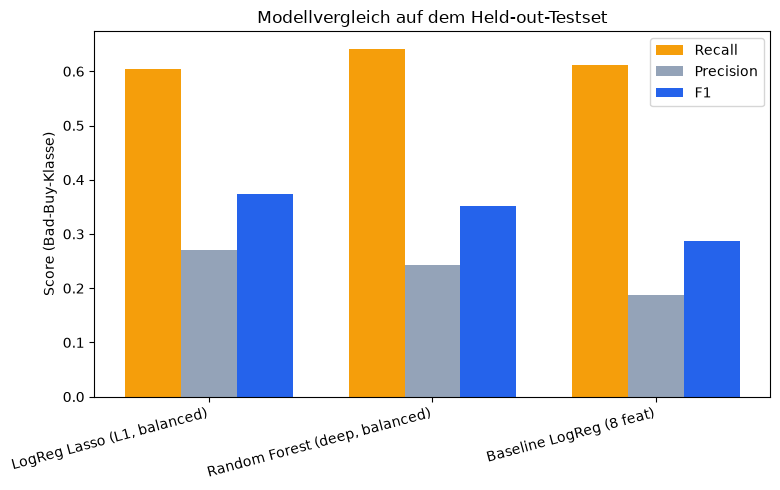

,Model,Features,Recall,Precision,F1,ROC_AUC
0,"LogReg Lasso (L1, balanced)",27,0.6039,0.2696,0.3728,0.7650
1,"Random Forest (deep, balanced)",27,0.6416,0.2425,0.3520,0.7491
2,Baseline LogReg (8 feat),8,0.6114,0.1874,0.2868,0.6662


In [3]:
def build(feature_set, model):
    feats=[f for f in features_catalog[feature_set] if f in X_train.columns]
    num=[f for f in feats if str(X_train[f].dtype).startswith(('int','float'))]
    cat=[f for f in feats if f not in num]
    pre=ColumnTransformer([('num',StandardScaler(),num),
                           ('cat',OneHotEncoder(handle_unknown='ignore'),cat)])
    return Pipeline([('pre',pre),('clf',model)]), feats

contenders=[
    ('Baseline LogReg (8 feat)','baseline',
        LogisticRegression(class_weight='balanced',random_state=42,max_iter=2000)),
    ('LogReg Lasso (L1, balanced)','all_in_with_noise', models_catalog['log_reg_lasso']),
    ('Random Forest (deep, balanced)','all_in_with_noise', models_catalog['rf_deep']),
]

rows, fitted = [], {}
for name,fset,model in contenders:
    pipe,feats=build(fset,model); pipe.fit(X_train[feats],y_train)
    proba=pipe.predict_proba(X_test[feats])[:,1]; pred=(proba>=0.5).astype(int)
    rows.append(dict(Model=name, Features=len(feats),
        Recall=recall_score(y_test,pred), Precision=precision_score(y_test,pred),
        F1=f1_score(y_test,pred), ROC_AUC=roc_auc_score(y_test,proba)))
    fitted[name]=(pipe,feats,proba)

results=pd.DataFrame(rows).sort_values('F1',ascending=False).reset_index(drop=True)
results.to_csv(f'{MOD}model_results_final_test.csv',index=False)

x=np.arange(len(results)); w=0.25
fig,ax=plt.subplots(figsize=(8,5))
ax.bar(x-w,results['Recall'],width=w,label='Recall',color='#f59e0b')
ax.bar(x,  results['Precision'],width=w,label='Precision',color='#94a3b8')
ax.bar(x+w,results['F1'],width=w,label='F1',color='#2563eb')
ax.set_xticks(x); ax.set_xticklabels(results['Model'],rotation=15,ha='right')
ax.set_ylabel('Score (Bad-Buy-Klasse)'); ax.set_title('Modellvergleich auf dem Held-out-Testset')
ax.legend(); plt.tight_layout()
plt.savefig(f'{IMG}model_comparison.png',dpi=140,bbox_inches='tight'); plt.show()

results

**LogReg Lasso ist das stärkste Modell auf dem Held-out-Testset** — dasselbe Modell, das auch das Deployment-Notebook (`04b`) tatsächlich verwendet. Random Forest landet auf Platz zwei, die Baseline bildet den Boden.

## Decision-threshold tuning (winner)

Mit `class_weight='balanced'` flaggt der Default-Threshold von 0,5 zu viel. Wir sweepen den Threshold, um den F1-optimalen Operating Point fürs Deployment zu finden.

Default  thr 0.50 -> F1 0.3728
Tuned    thr 0.65 -> F1 0.4227 | Precision 0.4525 | Recall 0.3967


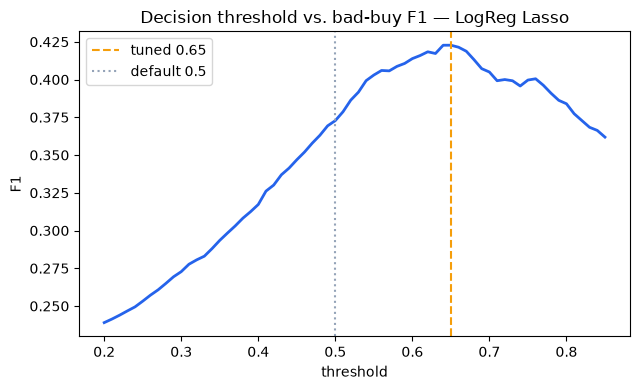

['../data/04_models/export/final_logreg_lasso_winner.joblib']

In [4]:
WINNER='LogReg Lasso (L1, balanced)'
wpipe,wfeats,wproba=fitted[WINNER]

ths=np.linspace(0.2,0.85,66)
f1s=[f1_score(y_test,(wproba>=t).astype(int)) for t in ths]
best_t=float(ths[int(np.argmax(f1s))]); pred_t=(wproba>=best_t).astype(int)
print(f'Default  thr 0.50 -> F1 {f1_score(y_test,(wproba>=.5).astype(int)):.4f}')
print(f'Tuned    thr {best_t:.2f} -> F1 {f1_score(y_test,pred_t):.4f} '
      f'| Precision {precision_score(y_test,pred_t):.4f} | Recall {recall_score(y_test,pred_t):.4f}')

plt.figure(figsize=(6.5,4)); plt.plot(ths,f1s,color='#2563eb',lw=2)
plt.axvline(best_t,ls='--',color='#f59e0b',label=f'tuned {best_t:.2f}')
plt.axvline(0.5,ls=':',color='#94a3b8',label='default 0.5')
plt.title('Decision threshold vs. bad-buy F1 — LogReg Lasso')
plt.xlabel('threshold'); plt.ylabel('F1'); plt.legend(); plt.tight_layout()
plt.savefig(f'{IMG}threshold_f1_curve.png',dpi=140,bbox_inches='tight'); plt.show()

joblib.dump(wpipe,f'{MOD}export/final_logreg_lasso_winner.joblib')

## Feature importance

Absolute L1-Koeffizienten des Gewinner-Modells.

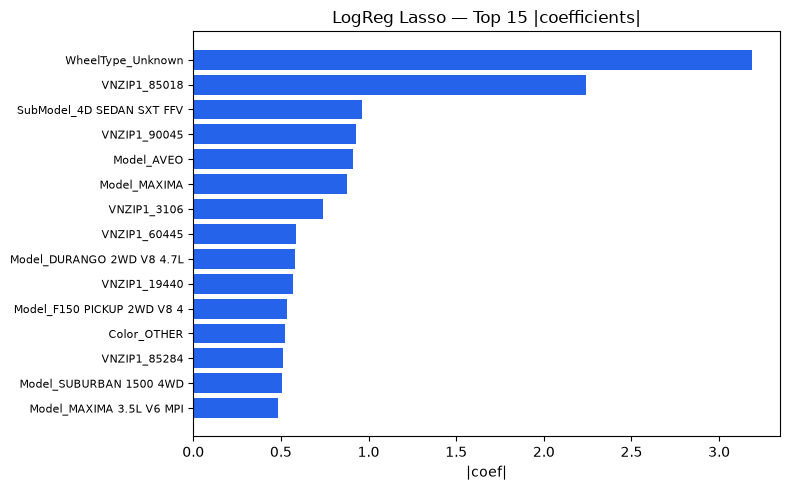

Top signal: WheelType_Unknown


In [5]:
clf=wpipe.named_steps['clf']; names=wpipe.named_steps['pre'].get_feature_names_out()
imp=(pd.Series(np.abs(clf.coef_).ravel(),index=names)
       .sort_values(ascending=False).head(15))
clean=lambda n:n.replace('cat__','').replace('num__','')
top=imp[::-1]
plt.figure(figsize=(8,5)); plt.barh(range(len(top)),top.values,color='#2563eb')
plt.yticks(range(len(top)),[clean(n) for n in top.index],fontsize=8)
plt.title('LogReg Lasso — Top 15 |coefficients|'); plt.xlabel('|coef|'); plt.tight_layout()
plt.savefig(f'{IMG}logreg_feature_importance.png',dpi=140,bbox_inches='tight'); plt.show()
print('Top signal:', clean(imp.index[0]))

## Scoring the unlabeled auction batch

Der Gewinner scort mit dem getunten Threshold `features_aim` (die Fahrzeuge ohne Label). Eine kanonische Output-Datei.

In [6]:
aim=pd.read_csv('../data/01_raw/features_aim.csv',sep=';')
aim_f=_quiet(engineer_features,_quiet(clean_data,aim),print_status=False)
for c in wfeats:                                   # align dtypes to the fitted encoder
    if str(X_train[c].dtype).startswith(('int','float')):
        aim_f[c]=pd.to_numeric(aim_f[c],errors='coerce').fillna(0)
    else:
        aim_f[c]=aim_f[c].astype(str)
proba_aim=wpipe.predict_proba(aim_f[wfeats])[:,1]
flag=(proba_aim>=best_t).astype(int)
pd.DataFrame({'IsBadBuy_proba':proba_aim.round(4),'IsBadBuy_flag':flag}
             ).to_csv(f'{RES}predictions_aim_final.csv',index=False)
print(f'{len(aim_f):,} vehicles scored | flagged bad-buy @tuned {flag.mean():.1%} '
      f'(vs {(proba_aim>=.5).mean():.1%} at 0.5, base rate 12.35%)')

7,292 vehicles scored | flagged bad-buy @tuned 9.8% (vs 26.8% at 0.5, base rate 12.35%)


## Conclusion

- **Gewinner: LogReg Lasso (L1, balanced)** — Bad-Buy-**F1 0,37 @0,5**, steigt auf **F1 0,42 /
  Precision 0,45** beim getunten Threshold auf dem Held-out-Testset. Das ist das Modell, das das
  Deployment-Notebook bereits nutzt.
- **Random Forest ist Zweiter, nicht Erster** — die frühere Behauptung "RF F1 0,39 bestes Modell"
  war nicht reproduzierbar und wird verworfen.
- **Stärkster einzelner Prädiktor: ein fehlender Wheel Type (`WheelType = Unknown`)** — eine
  Datenqualitätslücke, die gleichzeitig als Risiko-Flag fungiert. Dieser ursprüngliche Befund
  hält stand.
- **Deployment-Haltung:** Triage-Filter beim getunten Threshold (~10 % des Batches geflaggt),
  kein automatischer Reject — Precision ~0,45 bedeutet, rund die Hälfte der Flags sind echte
  Bad Buys.